In [1]:
from tensorflow.keras.datasets import mnist

# loading data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
# pixel normalization (0-255) -> (0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [4]:
y_train.shape, y_test.shape

((60000,), (10000,))

In [5]:
# one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
y_train.shape, y_test.shape

((60000, 10), (10000, 10))

In [7]:
# building model
# Flatten to transform 2D-image (28x28) to a 1D-vector (784)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28,28)), # input layer
    Dense(128, activation='relu'), # hidden layer 1
    Dense(64, activation='relu'), # hidden layer 2
    Dense(10, activation='softmax') # output layer
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# model compiling
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

In [9]:
# model training
history = model.fit(X_train, y_train,
                   epochs=10,
                   batch_size=32,
                   validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8606 - loss: 0.4661 - val_accuracy: 0.9597 - val_loss: 0.1380
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9632 - loss: 0.1215 - val_accuracy: 0.9690 - val_loss: 0.1025
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9780 - loss: 0.0748 - val_accuracy: 0.9706 - val_loss: 0.0969
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9819 - loss: 0.0569 - val_accuracy: 0.9700 - val_loss: 0.0945
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9875 - loss: 0.0401 - val_accuracy: 0.9753 - val_loss: 0.0874
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9894 - loss: 0.0314 - val_accuracy: 0.9738 - val_loss: 0.0994
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9904 - loss: 0.0293 - val_accuracy: 0.9738 - val_loss: 0.1005
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9939 - loss: 0.0199 - 

In [10]:
# accuracy test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9727 - loss: 0.1318
Test accuracy: 0.9753


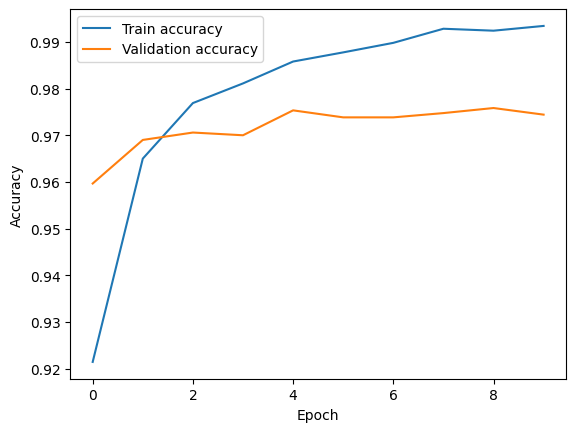

In [11]:
# results visualization
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
# prediction example
import numpy as np

sample_idx = np.random.randint(0, len(X_test))
sample_image = X_test[sample_idx]
sample_label = np.argmax(y_test[sample_idx])

prediction = model.predict(sample_image.reshape(1, 28, 28))
predicted_label = np.argmax(prediction)

print(f"True label: {sample_label}")
print(f"Predicted label: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
True label: 2
Predicted label: 2
